In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("train.csv")

In [3]:
df.shape

(1460, 81)

In [4]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [6]:
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


Data Cleaning

In [8]:
cols=['Id','Alley','PoolQC','Fence','MiscFeature','FireplaceQu','MasVnrType']
df.drop(columns=cols,inplace=True)

In [9]:
df.shape

(1460, 74)

In [10]:
missing_values=df.isnull().sum()
missing_values[missing_values>0].sort_values(ascending=False)

LotFrontage     259
GarageYrBlt      81
GarageFinish     81
GarageQual       81
GarageType       81
GarageCond       81
BsmtFinType2     38
BsmtExposure     38
BsmtQual         37
BsmtFinType1     37
BsmtCond         37
MasVnrArea        8
Electrical        1
dtype: int64

In [11]:
# 1. LotFrontage- about 17.7% missing values, numerical value
df.fillna({'LotFrontage':df['LotFrontage'].median()},inplace=True)
# 2. GarageYrBlt- about 5.5% missing values, numerical value, null means no garage exists
df.fillna({'GarageYrBlt':0},inplace=True)
# 3. GarageFinish, GarageType, GarageQual , GarageCond all are str or categorical values if no garage exists then fill it with none
df.fillna({'GarageFinish':'None'},inplace=True)
df.fillna({'GarageType':'None'},inplace=True)
df.fillna({'GarageQual':'None'},inplace=True)
df.fillna({'GarageCond':'None'},inplace=True)
# 4.BsmtFinType2,BsmtExposure, BsmtQual,BsmtFinType1, BsmtCond- about 2.5 to 2.6 % missing,these all are categorical columns, NULL signifies these properties do no have basement
df.fillna({'BsmtFinType2':'None'},inplace=True)
df.fillna({'BsmtExposure':'None'},inplace=True)
df.fillna({'BsmtQual':'None'},inplace=True)
df.fillna({'BsmtFinType1':'None'},inplace=True)
df.fillna({'BsmtCond':'None'},inplace=True)
# 5. MasVnrArea-about 0.5% missing, numerical value
df.fillna({'MasVnrArea':0},inplace=True)
# 6. Electrical -about 0.07% missing, categorical value
df.fillna({'Electrical':df['Electrical'].mode()[0]},inplace=True)

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,60,RL,65.0,8450,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,0,2,2008,WD,Normal,208500
1,20,RL,80.0,9600,Pave,Reg,Lvl,AllPub,FR2,Gtl,...,0,0,0,0,0,5,2007,WD,Normal,181500
2,60,RL,68.0,11250,Pave,IR1,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,0,9,2008,WD,Normal,223500
3,70,RL,60.0,9550,Pave,IR1,Lvl,AllPub,Corner,Gtl,...,272,0,0,0,0,2,2006,WD,Abnorml,140000
4,60,RL,84.0,14260,Pave,IR1,Lvl,AllPub,FR2,Gtl,...,0,0,0,0,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,60,RL,62.0,7917,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,0,8,2007,WD,Normal,175000
1456,20,RL,85.0,13175,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,0,2,2010,WD,Normal,210000
1457,70,RL,66.0,9042,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,2500,5,2010,WD,Normal,266500
1458,20,RL,68.0,9717,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,112,0,0,0,0,4,2010,WD,Normal,142125


In [12]:
df.isnull().sum()

MSSubClass       0
MSZoning         0
LotFrontage      0
LotArea          0
Street           0
                ..
MoSold           0
YrSold           0
SaleType         0
SaleCondition    0
SalePrice        0
Length: 74, dtype: int64

In [13]:
missing_cols=df.isnull().sum()
missing_cols[missing_cols>0].sort_values(ascending=False)


Series([], dtype: int64)

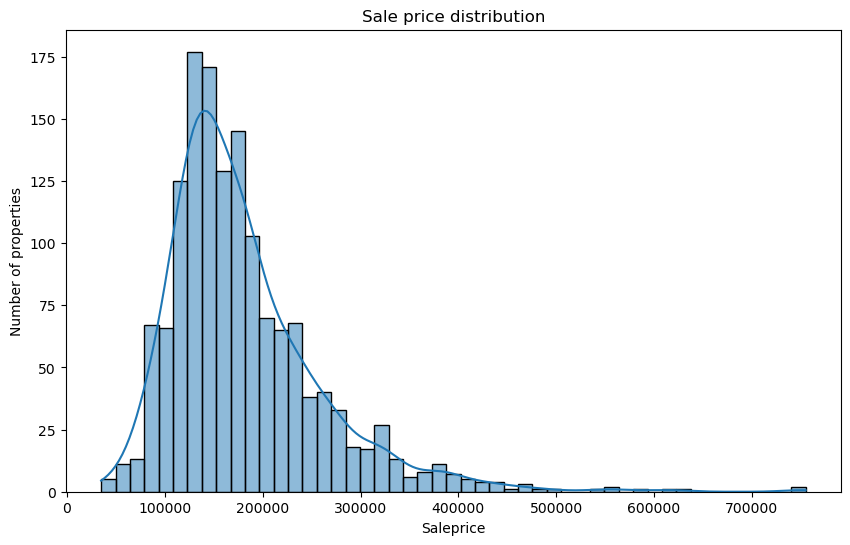

In [14]:
width=10
height=6
plt.figure(figsize=(width,height))
sns.histplot(df['SalePrice'],kde=True)
plt.title("Sale price distribution")
plt.xlabel("Saleprice")
plt.ylabel("Number of properties")
plt.show()
plt.close()

In [15]:
corr_matrix=df.corr(numeric_only=True)

In [16]:
top_features=corr_matrix['SalePrice'].abs().sort_values(ascending=False).head(10).index
top_features

Index(['SalePrice', 'OverallQual', 'GrLivArea', 'GarageCars', 'GarageArea',
       'TotalBsmtSF', '1stFlrSF', 'FullBath', 'TotRmsAbvGrd', 'YearBuilt'],
      dtype='str')

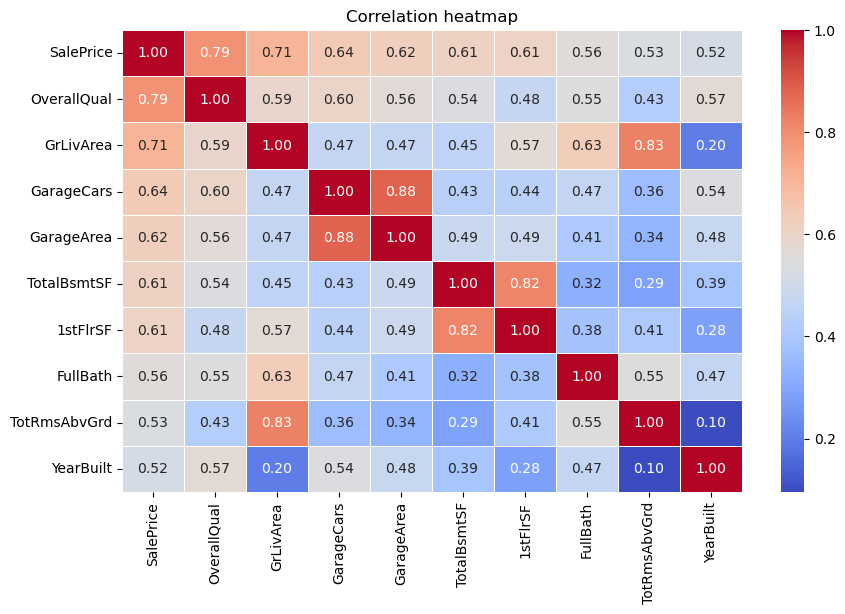

In [17]:
width=10
height=6
plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix[top_features].loc[top_features], annot=True, cmap='coolwarm',fmt='.2f',linewidths=0.5)
plt.title("Correlation heatmap")
plt.show()
plt.close()


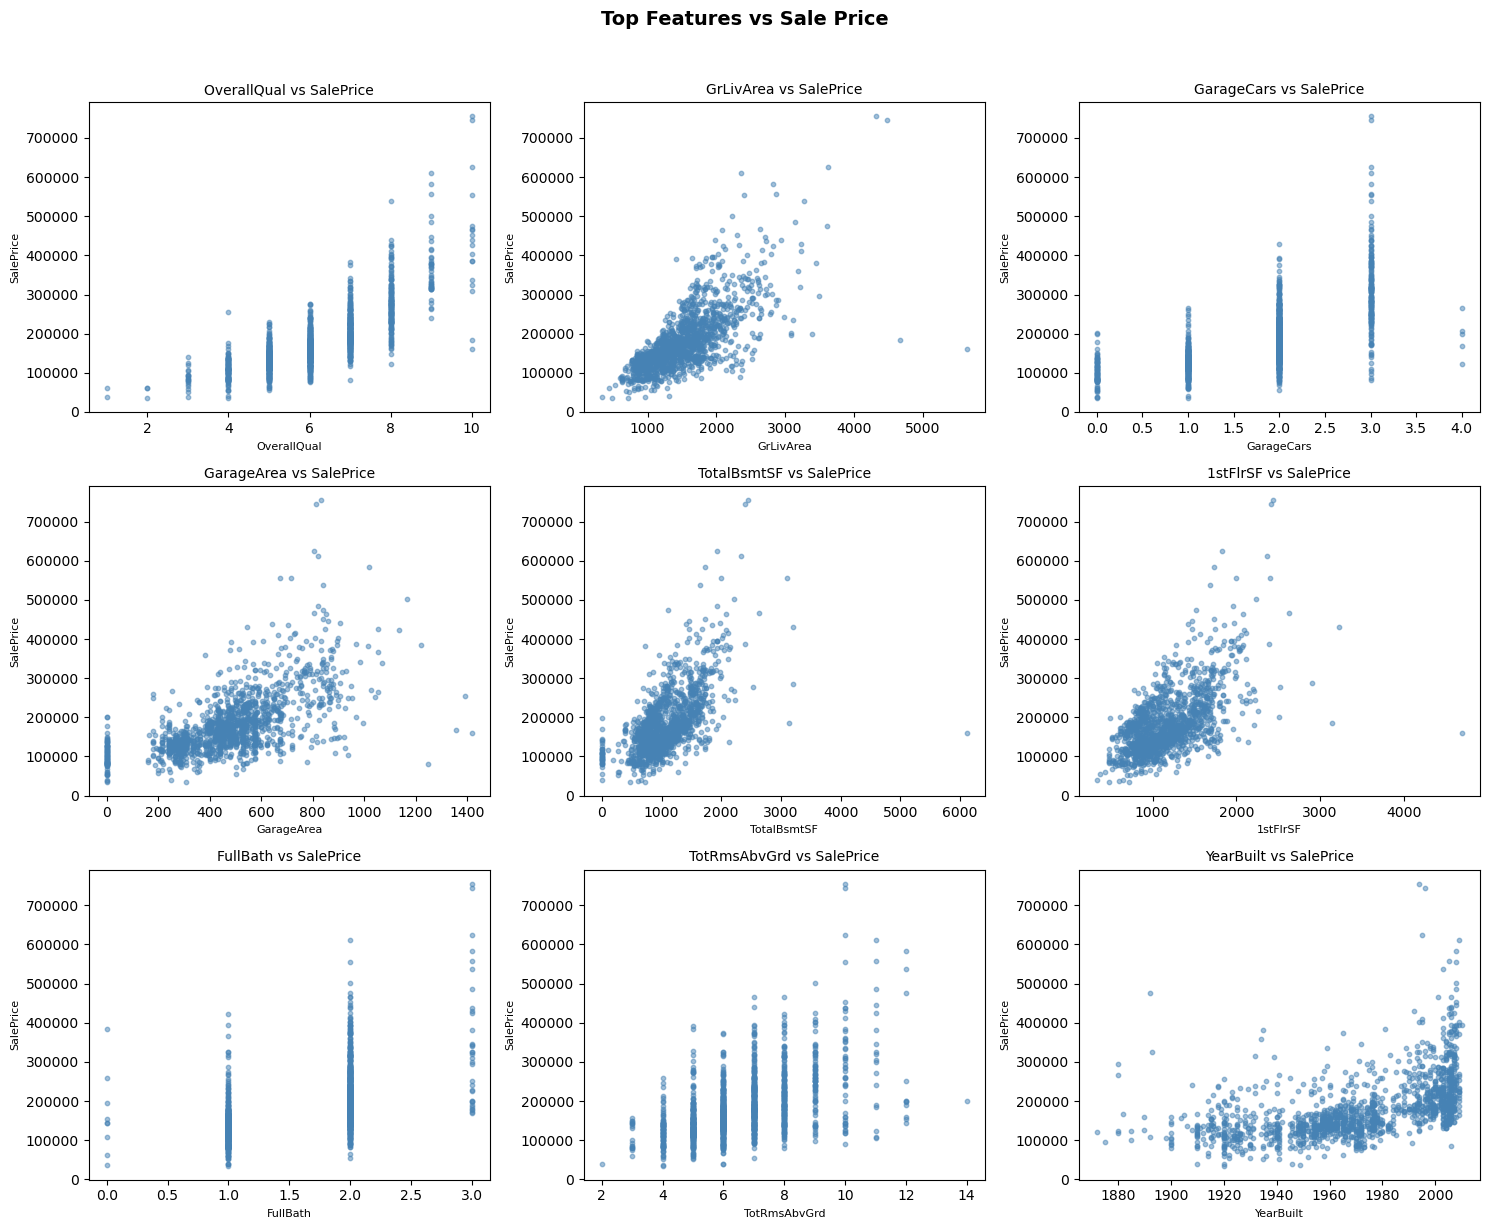

In [35]:
features = [f for f in top_features if f != 'SalePrice']

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, (feature, ax) in enumerate(zip(features, axes)):
    ax.scatter(df[feature], df['SalePrice'], 
               alpha=0.5, color='steelblue', s=10)
    ax.set_title(f'{feature} vs SalePrice', fontsize=10)
    ax.set_xlabel(feature, fontsize=8)
    ax.set_ylabel('SalePrice', fontsize=8)

plt.suptitle('Top Features vs Sale Price', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
plt.close()

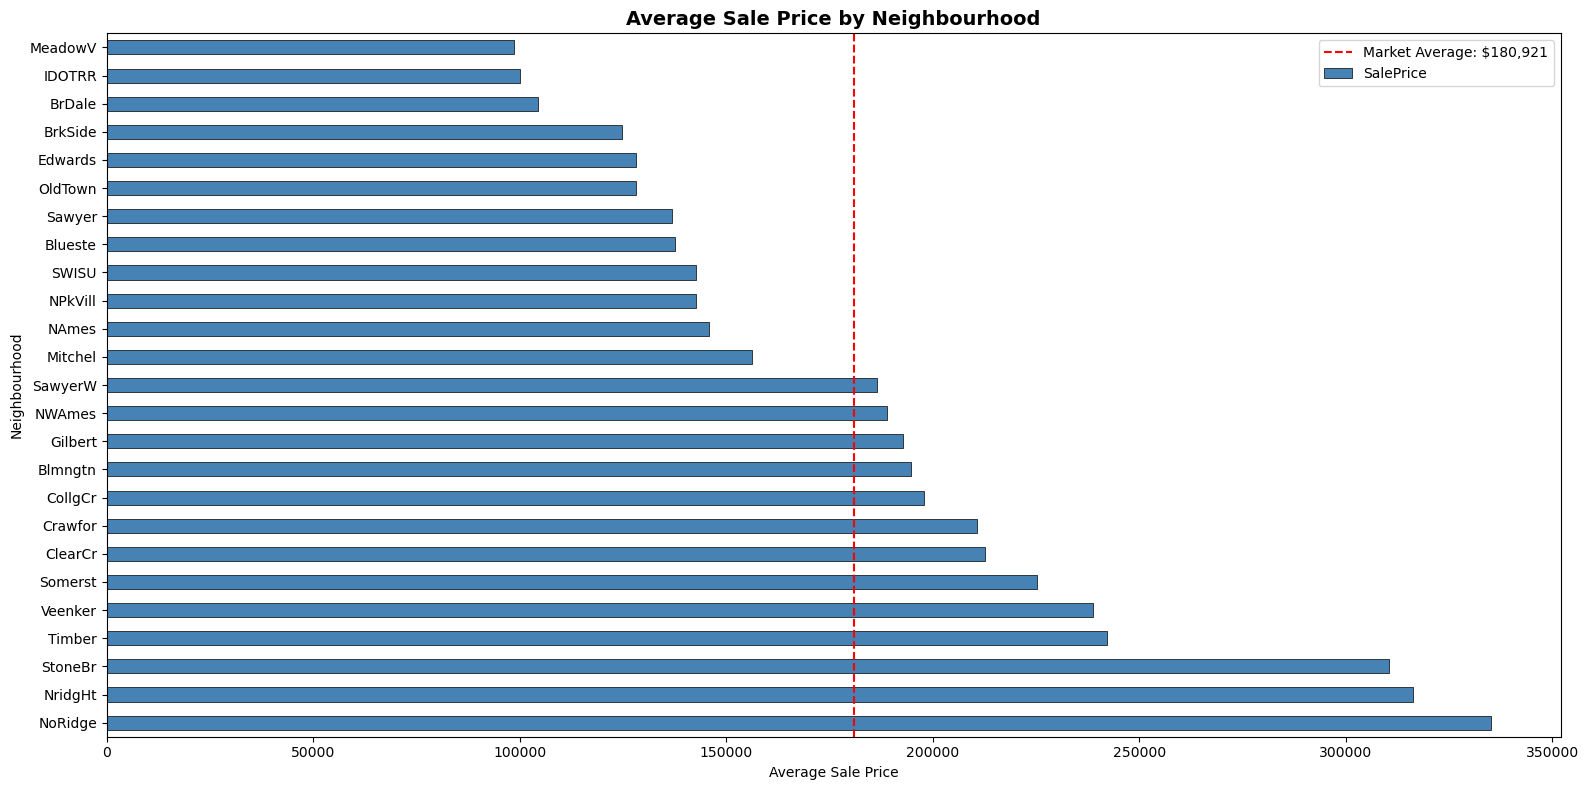

In [37]:
neighbourhood_avg = df.groupby('Neighborhood')['SalePrice'].mean().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(16, 8))
neighbourhood_avg.plot(kind='barh', ax=ax, color='steelblue', edgecolor='black', linewidth=0.5)

ax.axvline(df['SalePrice'].mean(), color='red', linestyle='--', linewidth=1.5, label=f'Market Average: ${df["SalePrice"].mean():,.0f}')
ax.set_title('Average Sale Price by Neighbourhood', fontsize=14, fontweight='bold')
ax.set_xlabel('Average Sale Price', fontsize=10)
ax.set_ylabel('Neighbourhood', fontsize=10)
ax.legend()
plt.tight_layout()
plt.show()
plt.close()

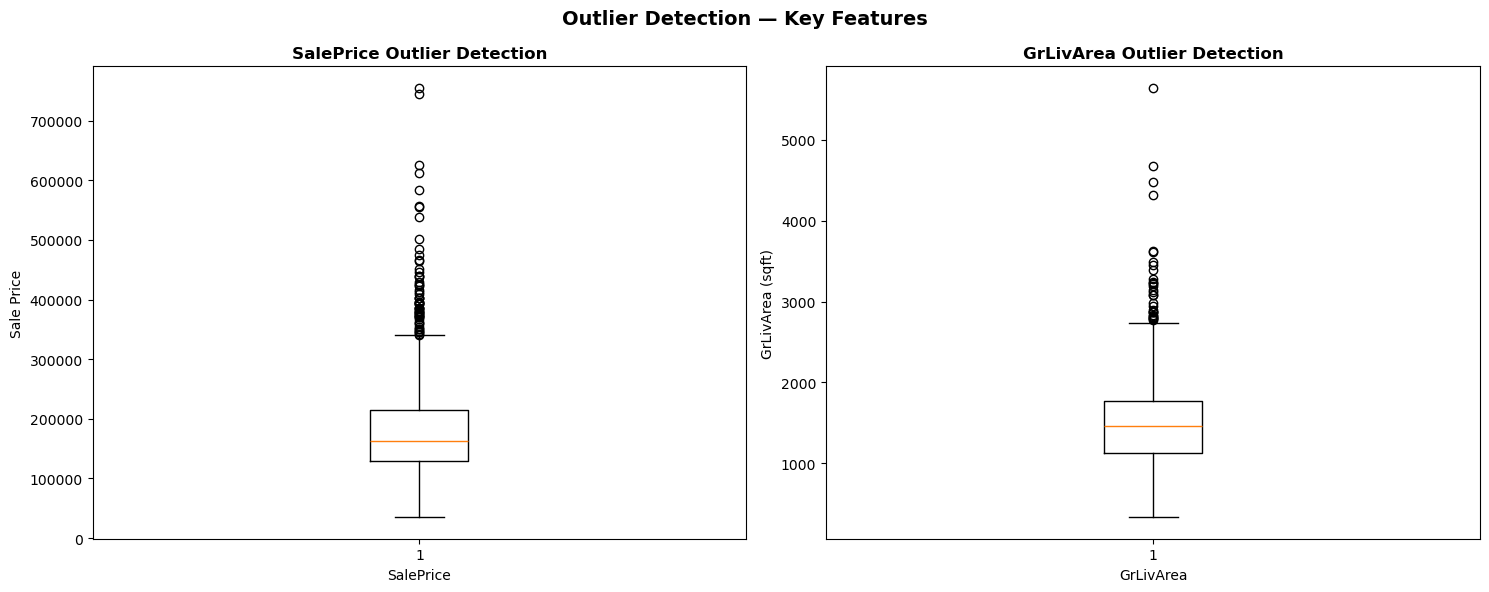

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].boxplot(df['SalePrice'], vert=True)
axes[0].set_title('SalePrice Outlier Detection', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Sale Price', fontsize=10)
axes[0].set_xlabel('SalePrice', fontsize=10)

axes[1].boxplot(df['GrLivArea'], vert=True)
axes[1].set_title('GrLivArea Outlier Detection', fontsize=12, fontweight='bold')
axes[1].set_ylabel('GrLivArea (sqft)', fontsize=10)
axes[1].set_xlabel('GrLivArea', fontsize=10)

plt.suptitle('Outlier Detection — Key Features', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
plt.close()

In [41]:
# Outlier remove
# Remove GrLivArea outliers above 4000 sqft These are abnormally large properties that distort the model
df = df[df['GrLivArea'] < 4000]

print(f'Dataset shape after outlier removal: {df.shape}')

Dataset shape after outlier removal: (1456, 74)


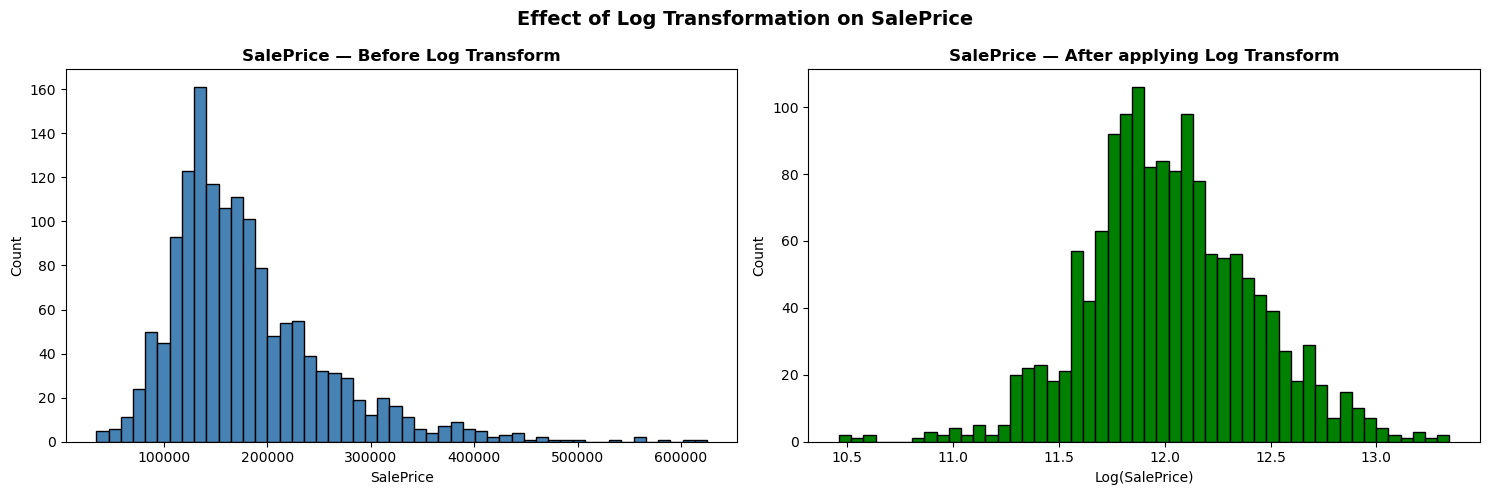

In [45]:
df['SalePrice_log'] = np.log(df['SalePrice'])

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Before transformation
axes[0].hist(df['SalePrice'], bins=50, color='steelblue', edgecolor='black')
axes[0].set_title('SalePrice — Before Log Transform', fontsize=12, fontweight='bold')
axes[0].set_xlabel('SalePrice')
axes[0].set_ylabel('Count')

# After transformation
axes[1].hist(df['SalePrice_log'], bins=50, color='green', edgecolor='black')
axes[1].set_title('SalePrice — After applying Log Transform', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Log(SalePrice)')
axes[1].set_ylabel('Count')

plt.suptitle('Effect of Log Transformation on SalePrice',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
plt.close()

In [47]:
# Feature 1 — Property Age at time of sale
df['property_age'] = df['YrSold'] - df['YearBuilt']

# Feature 2 — Years since last remodel
df['years_since_remodel'] = df['YrSold'] - df['YearRemodAdd']

# Feature 3 — Total bathrooms
df['total_bathrooms'] = (df['FullBath'] + df['HalfBath'] + 
                         df['BsmtFullBath'] + df['BsmtHalfBath'])

# Feature 4 — Total square footage
df['total_sqft'] = df['TotalBsmtSF'] + df['GrLivArea']

# Feature 5 — Has garage (binary)
df['has_garage'] = (df['GarageArea'] > 0).astype(int)

# Feature 6 — Has basement (binary)
df['has_basement'] = (df['TotalBsmtSF'] > 0).astype(int)

# Verify new features created
new_features = ['property_age', 'years_since_remodel', 
                'total_bathrooms', 'total_sqft',
                'has_garage', 'has_basement']
print(df[new_features].head())
print(f'\nDataset shape after feature creation: {df.shape}')

   property_age  years_since_remodel  total_bathrooms  total_sqft  has_garage  \
0             5                    5                4        2566           1   
1            31                   31                3        2524           1   
2             7                    6                4        2706           1   
3            91                   36                2        2473           1   
4             8                    8                4        3343           1   

   has_basement  
0             1  
1             1  
2             1  
3             1  
4             1  

Dataset shape after feature creation: (1456, 81)


In [51]:
# Feature encoding

categorical_cols = df.select_dtypes(include='str').columns.tolist()
print(f'Categorical columns to encode: {len(categorical_cols)}')
print(categorical_cols)
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print(f'\nShape before encoding: {df.shape}')
print(f'Shape after encoding:  {df_encoded.shape}')

Categorical columns to encode: 37
['MSZoning', 'Street', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'SaleType', 'SaleCondition']

Shape before encoding: (1456, 81)
Shape after encoding:  (1456, 245)


In [53]:
# Feature scaling
from sklearn.preprocessing import StandardScaler

X = df_encoded.drop(['SalePrice', 'SalePrice_log'], axis=1)
y = df_encoded['SalePrice_log']

numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

scaler = StandardScaler()
X[numerical_cols] = scaler.fit_transform(X[numerical_cols])

print(f'Features shape: {X.shape}')
print(f'Target shape:   {y.shape}')
print(f'\nSample of scaled values:')
print(X[numerical_cols].head(3))

Features shape: (1456, 243)
Target shape:   (1456,)

Sample of scaled values:
   MSSubClass  LotFrontage   LotArea  OverallQual  OverallCond  YearBuilt  \
0    0.073476    -0.218699 -0.202770     0.665646    -0.517461   1.053769   
1   -0.871172     0.499122 -0.086107    -0.064709     2.176545   0.159469   
2    0.073476    -0.075135  0.081281     0.665646    -0.517461   0.987524   

   YearRemodAdd  MasVnrArea  BsmtFinSF1  BsmtFinSF2  ...  PoolArea   MiscVal  \
0      0.880629    0.533895    0.625446   -0.289082  ... -0.058115 -0.087809   
1     -0.427190   -0.573757    1.257846   -0.289082  ... -0.058115 -0.087809   
2      0.832191    0.341751    0.113946   -0.289082  ... -0.058115 -0.087809   

     MoSold    YrSold  property_age  years_since_remodel  total_bathrooms  \
0 -1.603837  0.137472     -1.046125            -0.872028         1.725114   
1 -0.491667 -0.615009     -0.186256             0.387712         0.630663   
2  0.991227  0.137472     -0.979982            -0.823576     

In [55]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print(f'Training set:  {X_train.shape}')
print(f'Testing set:   {X_test.shape}')
print(f'Training target: {y_train.shape}')
print(f'Testing target:  {y_test.shape}')

Training set:  (1164, 243)
Testing set:   (292, 243)
Training target: (1164,)
Testing target:  (292,)


In [57]:
# Linear Regression
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_predictions = lr_model.predict(X_test)

print(f'Linear Regression Training Score: {lr_model.score(X_train, y_train):.4f}')
print(f'Linear Regression Testing Score:  {lr_model.score(X_test, y_test):.4f}')

Linear Regression Training Score: 0.9512
Linear Regression Testing Score:  0.8947


In [59]:
# Polynomial Regression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline

poly_model = Pipeline([('poly', PolynomialFeatures(degree=2,include_bias=False)),('linear', LinearRegression())])
poly_model.fit(X_train, y_train)
poly_predictions = poly_model.predict(X_test)

print(f'Polynomial Regression Training Score: {poly_model.score(X_train, y_train):.4f}')
print(f'Polynomial Regression Testing Score:  {poly_model.score(X_test, y_test):.4f}')

Polynomial Regression Training Score: 1.0000
Polynomial Regression Testing Score:  0.8023


In [61]:
# Random Forest Regressor
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=100,max_depth=15,min_samples_split=5,min_samples_leaf=2,random_state=42,n_jobs=-1)

rf_model.fit(X_train, y_train)
rf_predictions = rf_model.predict(X_test)

print(f'Random Forest Training Score: {rf_model.score(X_train, y_train):.4f}')
print(f'Random Forest Testing Score:  {rf_model.score(X_test, y_test):.4f}')

Random Forest Training Score: 0.9751
Random Forest Testing Score:  0.8652


In [65]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

def evaluate_model(name, model, y_test, predictions):
    # Converting log predictions back to actual prices
    y_test_actual = np.exp(y_test)
    predictions_actual = np.exp(predictions)
    
    
    mae  = mean_absolute_error(y_test_actual, predictions_actual)
    rmse = np.sqrt(mean_squared_error(y_test_actual, predictions_actual))
    r2   = model.score(X_test, y_test)
    
    print(f'\n{name}:')
    print(f'  MAE  : ${mae:,.0f}')
    print(f'  RMSE : ${rmse:,.0f}')
    print(f'  R²   : {r2:.4f}')
    return mae, rmse, r2

# Evaluate all three models
lr_mae,   lr_rmse,   lr_r2   = evaluate_model('Linear Regression',    lr_model,   y_test, lr_predictions)
poly_mae, poly_rmse, poly_r2 = evaluate_model('Polynomial Regression', poly_model, y_test, poly_predictions)
rf_mae,   rf_rmse,   rf_r2   = evaluate_model('Random Forest',         rf_model,   y_test, rf_predictions)


Linear Regression:
  MAE  : $14,641
  RMSE : $20,743
  R²   : 0.8947

Polynomial Regression:
  MAE  : $21,204
  RMSE : $29,363
  R²   : 0.8023

Random Forest:
  MAE  : $16,969
  RMSE : $24,484
  R²   : 0.8652


In [67]:
# Feature importances-

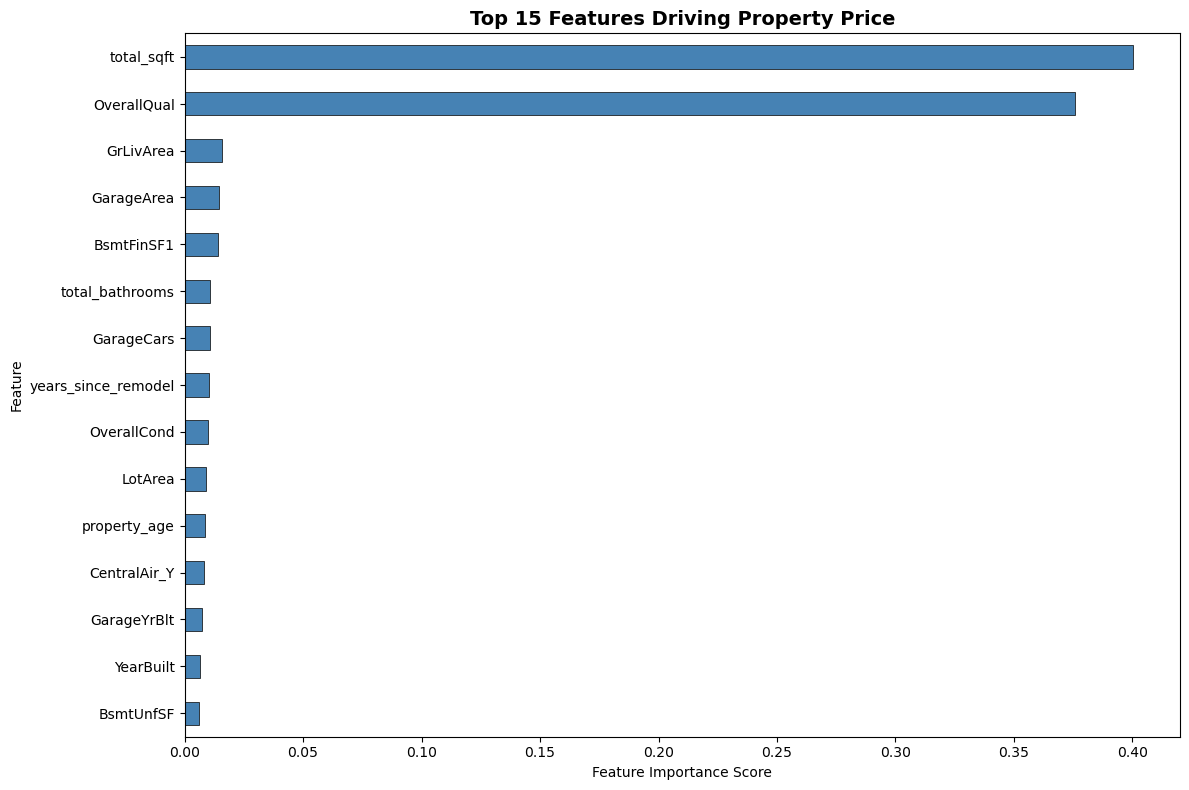


Top 15 Price Driving Features:
total_sqft             0.400092
OverallQual            0.375934
GrLivArea              0.015615
GarageArea             0.014672
BsmtFinSF1             0.014063
total_bathrooms        0.010713
GarageCars             0.010613
years_since_remodel    0.010076
OverallCond            0.009763
LotArea                0.009123
property_age           0.008582
CentralAir_Y           0.008156
GarageYrBlt            0.007448
YearBuilt              0.006499
BsmtUnfSF              0.006044
dtype: float64


In [69]:
feature_importance = pd.Series(rf_model.feature_importances_,index=X.columns).sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(12, 8))

feature_importance.plot(kind='barh',ax=ax,color='steelblue',edgecolor='black',linewidth=0.5)

ax.set_title('Top 15 Features Driving Property Price',fontsize=14, fontweight='bold')
ax.set_xlabel('Feature Importance Score', fontsize=10)
ax.set_ylabel('Feature', fontsize=10)
ax.invert_yaxis()
plt.tight_layout()
plt.show()
plt.close()

print('\nTop 15 Price Driving Features:')
print(feature_importance)

In [73]:
# Final Model Comparison
print('Model Comparisson')
print('-' * 45)
print(f'{"Model":<25} {"MAE":>8} {"RMSE":>10} {"R²":>8}')
print('-' * 45)
print(f'{"Linear Regression":<25} {"$14,641":>8} {"$20,743":>10} {"0.8947":>8}')
print(f'{"Polynomial Regression":<25} {"$21,204":>8} {"$29,363":>10} {"0.8023":>8}')
print(f'{"Random Forest":<25} {"$16,969":>8} {"$24,484":>10} {"0.8652":>8}')
print('-' * 45)

# Winning Model
print('\nWinning model → Linear Regression')
print(f'  Average prediction error : $14,641')
print(f'  Price variation explained : 89.47%')

# Top Price Drivers
print('\nTop saleprice drivers  (Random Forest):')
print(f'  1. Total Square Footage : 40.01%')
print(f'  2. Overall Quality      : 37.59%')
print(f'  3. Combined             : 77.60%')

# Key Business Insight
print('\n Business Insights:')
print('  Just two features explain 78% of')
print('  property price variation.')
print('  Total space + Quality = Price.')

Model Comparisson
---------------------------------------------
Model                          MAE       RMSE       R²
---------------------------------------------
Linear Regression          $14,641    $20,743   0.8947
Polynomial Regression      $21,204    $29,363   0.8023
Random Forest              $16,969    $24,484   0.8652
---------------------------------------------

Winning model → Linear Regression
  Average prediction error : $14,641
  Price variation explained : 89.47%

Top saleprice drivers  (Random Forest):
  1. Total Square Footage : 40.01%
  2. Overall Quality      : 37.59%
  3. Combined             : 77.60%

 Business Insights:
  Just two features explain 78% of
  property price variation.
  Total space + Quality = Price.


In [81]:
df['size_category'] = pd.cut(df['GrLivArea'],bins=[0, 999, 1999, 2999, float('inf')],labels=['Small', 'Medium', 'Large', 'Very Large'])


df['decade_built'] = pd.cut(df['YearBuilt'], bins=[1871, 1891, 1911, 1931, 1951, 1971, 1991, 2011],labels=['1872-1891', '1892-1911', '1912-1931',
            '1932-1951', '1952-1971', '1972-1991', '1992-2010'])


tableau_cols = [
    # Location
    'Neighborhood', 'MSZoning',

    # Size
    'GrLivArea', 'TotalBsmtSF',
    'LotArea', 'GarageArea',
    'total_sqft',

    # Quality & Condition
    'OverallQual', 'OverallCond',

    # Age
    'YearBuilt', 'YearRemodAdd',
    'property_age', 'years_since_remodel',
    'decade_built',

    # Configuration
    'BedroomAbvGr', 'FullBath',
    'total_bathrooms', 'Fireplaces',
    'CentralAir',

    # Size Category
    'size_category',

    # Target
    'SalePrice', 'SalePrice_log'
]

# Step 3 — Export to CSV
df[tableau_cols].to_csv('real_estate_tableau.csv', index=False)

# Step 4 — Verify export
print(f'Columns exported : {len(tableau_cols)}')
print(f'Shape            : {df[tableau_cols].shape}')
print(f'\nColumn list:')
for col in tableau_cols:
    print(f'  : {col}')

Columns exported : 22
Shape            : (1456, 22)

Column list:
  : Neighborhood
  : MSZoning
  : GrLivArea
  : TotalBsmtSF
  : LotArea
  : GarageArea
  : total_sqft
  : OverallQual
  : OverallCond
  : YearBuilt
  : YearRemodAdd
  : property_age
  : years_since_remodel
  : decade_built
  : BedroomAbvGr
  : FullBath
  : total_bathrooms
  : Fireplaces
  : CentralAir
  : size_category
  : SalePrice
  : SalePrice_log
